<a href="https://colab.research.google.com/github/HaiderCortex/Machine-learning/blob/main/4.%20feature%20selection%20/embbeded_Method_feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Embedded method


#lasso regularization feature selection

In [4]:


from sklearn import datasets
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
X = df.iloc[: , 0: -1]
y = df.iloc[: , -1]


X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.2 , random_state = 1)

In [10]:
cols = X_train.columns

scal = StandardScaler()

X_train_scaled = scal.fit_transform(X_train)
X_test_scaled = scal.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled , columns = cols)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = cols)

In [13]:
from sklearn.linear_model import Lasso

lasso  = Lasso(alpha=0.01)

lasso.fit(X_train_scaled,y_train)

Lasso(alpha=0.01)

In [16]:
coef = lasso.coef_
coef


array([ 6.26290474e-02,  1.85968700e-01, -3.50258983e-02, -0.00000000e+00,
       -1.62558777e-04,  8.51781764e-02,  2.83810683e-02,  1.84611338e-02])

In [18]:
x = pd.Series(np.abs(coef) , index = cols)
x

,0
Pregnancies,0.062629
Glucose,0.185969
BloodPressure,0.035026
SkinThickness,0.000000
Insulin,0.000163
BMI,0.085178
DiabetesPedigreeFunction,0.028381
Age,0.018461


<Axes: >

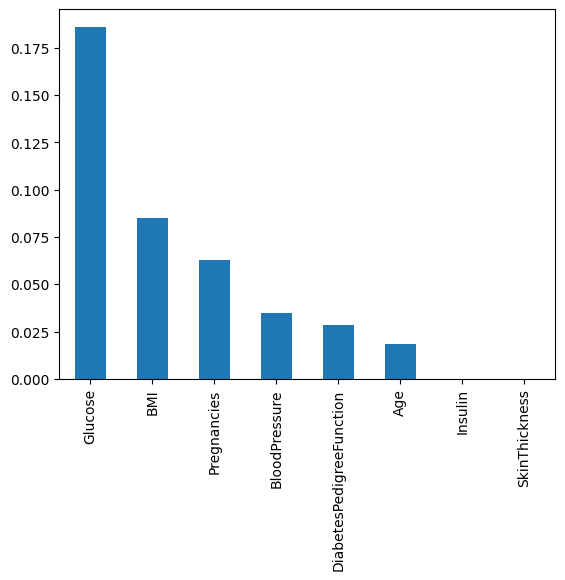

In [22]:
x.sort_values(ascending=False).plot(kind = "bar")

# Decesion Tree embedded method

In [24]:


from sklearn import datasets
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
X = df.iloc[: , 0: -1]
y = df.iloc[: , -1]


X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.2 , random_state = 1)

In [26]:
cols = X_train.columns

scal = StandardScaler()

X_train_scaled = scal.fit_transform(X_train)
X_test_scaled = scal.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled , columns = cols)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = cols)

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


#dt = DecisionTreeClassifier(max_features=5)
rf = RandomForestClassifier()
#dt.fit(X_train_scaled,y_train)
rf.fit(X_train_scaled,y_train)

RandomForestClassifier()

In [37]:
coef = rf.feature_importances_
coef


array([0.07977933, 0.25252959, 0.09264927, 0.06853101, 0.0780018 ,
       0.17030612, 0.12169189, 0.13651101])

<Axes: >

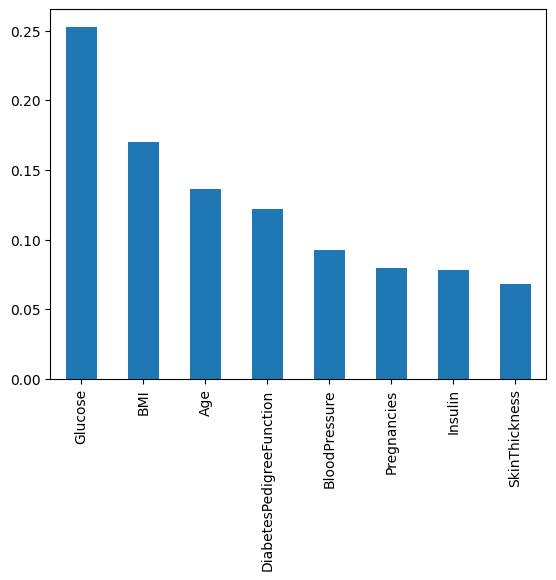

In [38]:
x = pd.Series(np.abs(coef) , index = cols)
x.sort_values(ascending=False).plot(kind = "bar")

# SelectfromModel transformer

In [ ]:

from sklearn import datasets
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')
df.head()

In [ ]:
X = df.iloc[: , 0: -1]
y = df.iloc[: , -1]


X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.2 , random_state = 1)

In [ ]:
cols = X_train.columns

scal = StandardScaler()

X_train_scaled = scal.fit_transform(X_train)
X_test_scaled = scal.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled , columns = cols)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = cols)

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel


dt = DecisionTreeClassifier(max_features=5)
sfm = SelectFromModel(dt,threshold=0.1)
sfm.fit(X_train_scaled,y_train)



SelectFromModel(estimator=DecisionTreeClassifier(max_features=5), threshold=0.1)

In [40]:
sfm.get_support(indices=True)

array([1, 2, 5, 6, 7])

In [43]:
sfm.feature_names_in_[sfm.get_support(indices=True)]

array(['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction',
       'Age'], dtype=object)

In [45]:

X_train_trans = sfm.transform(X_train)

X_train_trans = pd.DataFrame(X_train_trans , columns =sfm.feature_names_in_[sfm.get_support(indices=True)])
X_train_trans

,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,145.0,80.0,37.9,0.637,40.0
1,129.0,62.0,41.2,0.441,38.0
2,102.0,74.0,37.2,0.204,45.0
3,120.0,78.0,25.0,0.409,64.0
4,120.0,76.0,39.7,0.215,29.0
...,...,...,...,...,...
609,157.0,74.0,39.4,0.134,30.0
610,187.0,50.0,33.9,0.826,34.0
611,126.0,90.0,43.4,0.583,42.0
612,171.0,72.0,43.6,0.479,26.0


<Axes: >

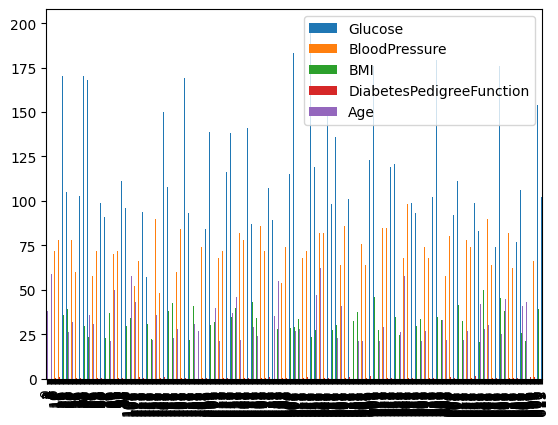

# Recursive feature selection wrapper method

In [48]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


url = "https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"

data  = pd.read_csv(url)
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [49]:
X = data.iloc[: , 0: -1]
y = data.iloc[: , -1]

In [56]:
dt = DecisionTreeClassifier()
rfe = RFE(estimator=dt, n_features_to_select=1)

rfe.fit(X,y)

RFE(estimator=DecisionTreeClassifier(), n_features_to_select=1)

In [57]:
ranking = rfe.ranking_
ranking

array([3, 4, 2, 1])

In [58]:
for i , features in enumerate(X.columns):
  print(f"{features} : {ranking[i]}")

sepal_length : 3
sepal_width : 4
petal_length : 2
petal_width : 1


In [62]:
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


url = "https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"

data  = pd.read_csv(url)
data.head()

X = data.iloc[: , 0: -1]
y = data.iloc[: , -1]

dt = DecisionTreeClassifier()
rfecv = RFECV(estimator=dt,step = 1 , cv = 5)

rfecv.fit(X,y)

ranking = rfecv.ranking_
ranking

for i , features in enumerate(X.columns):
  print(f"{features} : {ranking[i]}")


sepal_length : 1
sepal_width : 1
petal_length : 1
petal_width : 1


# Mutual info Filter method

In [69]:
from sklearn.feature_selection import SelectKBest , mutual_info_classif
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np


url = "https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"

data  = pd.read_csv(url)
data.head()

X = data.iloc[: , 0: -1]
y = data.iloc[: , -1]

selector = SelectKBest(mutual_info_classif , k = 2)

X_new = selector.fit_transform(X,y)

cols = selector.get_support(indices=True)
print(data.columns)
print(cols)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
[2 3]
